# DUOC UC
## Estadística Descriptiva

---

# Informe de análisis descriptivo
## Matrículas de educación superior en Arica y Parinacota
### Datos del año 2021 —  Avance 1

**Integrantes:** 
* Benjamín Cubillos
* Renato Troncoso
* Cristobal Pardo

**Docente:** Israel Barrera

**Sección:** 003D

**Fecha de entrega:** 09/09/2026

---

**Contenido de esta entrega**

Informe grupal de análisis descriptivo de ocho variables de la base de matrículas de educación superior: cuatro cuantitativas y cuatro cualitativas. El avance contempla tablas de frecuencias, gráficos, medidas de tendencia central y percentiles, según corresponda al tipo de variable, con comentarios e interpretaciones de los resultados. Las preguntas del Ítem 2 se presentan en una sección independiente.

---


## Introducción

El presente informe tiene como objetivo describir el conjunto de datos de matrículas de educación superior de Arica y Parinacota correspondiente a 2021. El trabajo grupal contempla el estudio de **ocho variables: cuatro cuantitativas y cuatro cualitativas**, seleccionadas por su pertinencia para caracterizar las matrículas registradas.

Para el **Ítem 1 de este avance**, se presentan tablas de frecuencias, gráficos, medidas de tendencia central y percentiles cuando corresponden al tipo de variable. Cada resultado se acompaña de una interpretación. En las variables cualitativas nominales se utilizan frecuencias, porcentajes y moda; no se calculan medias ni percentiles. Las preguntas del **Ítem 2** se desarrollan por separado, explicando el criterio utilizado y las limitaciones de cada respuesta.

La unidad de análisis es un registro de matrícula, que no necesariamente representa una persona o una carrera única. Los resultados describen este archivo y no se generalizan a otras regiones o años.

### Variables seleccionadas

| Variable | Clasificación | Descripción |
|---|---|---|
| Duración total de la carrera | Cuantitativa discreta | Duración registrada en semestres. |
| Edad | Cuantitativa discreta en este archivo | Edad registrada en años enteros. |
| Valor del arancel | Cuantitativa | Importe del arancel registrado en pesos. |
| Valor de matrícula | Cuantitativa | Importe de matrícula registrado en pesos. |
| Género | Cualitativa nominal | Género registrado. |
| Área de conocimiento | Cualitativa nominal | Área a la que pertenece la carrera. |
| Tipo de institución | Cualitativa nominal | Categoría de institución de educación superior. |
| Jornada | Cualitativa nominal | Jornada registrada para la matrícula. |

Se analizan cuatro variables cuantitativas y cuatro cualitativas. El rango de edad y el nombre de institución se usan como información complementaria, sin contarlos como variables adicionales del análisis principal. Los importes monetarios se analizan agrupados en intervalos; están registrados en pesos enteros.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

df = pd.read_excel('01_MATRICULAS_ED_SUPERIOR_ARICA_Y_PARINACOTA_2021.xlsx')

duracion = df['DURACION TOTAL CARRERA (SEMESTRES)']
genero = df['GENERO']
area = df['AREA CONOCIMIENTO']

pd.options.display.float_format = '{:,.2f}'.format
plt.rcParams.update({'figure.figsize': (10, 5), 'axes.spines.top': False,
                     'axes.spines.right': False})

print(f'Total de registros: {len(df):,}')
display(df[['DURACION TOTAL CARRERA (SEMESTRES)', 'GENERO', 'AREA CONOCIMIENTO']].head())

Total de registros: 14,116


,DURACION TOTAL CARRERA (SEMESTRES),GENERO,AREA CONOCIMIENTO
0,5,Femenino,Salud
1,4,Femenino,Administracion y Comercio
2,10,Masculino,Salud
3,10,Femenino,Salud
4,10,Femenino,Educacion


## 1. Revisión de los datos
Antes de calcular las medidas se revisan los valores faltantes, los identificadores repetidos y las duraciones no positivas. No se eliminan registros automáticamente: una duración poco frecuente no implica por sí sola un error.

In [2]:
variables = ['DURACION TOTAL CARRERA (SEMESTRES)', 'EDAD', 'VALOR ARANCEL (PESOS)',
             'VALOR MATRICULA (PESOS)', 'GENERO', 'AREA CONOCIMIENTO',
             'TIPO DE INSTITUCION', 'JORNADA']
revision = pd.DataFrame({
    'Tipo de dato': df[variables].dtypes.astype(str),
    'Valores válidos': df[variables].notna().sum(),
    'Valores faltantes': df[variables].isna().sum()
})
display(revision)
print('Identificadores repetidos:', df['ID'].duplicated().sum())
print('Duraciones menores o iguales a cero:', (duracion <= 0).sum())
print('Categorías de género:', genero.dropna().unique().tolist())
print('Cantidad de áreas:', area.nunique())

Identificadores repetidos: 0
Duraciones menores o iguales a cero: 0
Categorías de género: ['Femenino', 'Masculino']
Cantidad de áreas: 10


,Tipo de dato,Valores válidos,Valores faltantes
DURACION TOTAL CARRERA (SEMESTRES),int64,14116,0
EDAD,int64,14116,0
VALOR ARANCEL (PESOS),int64,14116,0
VALOR MATRICULA (PESOS),int64,14116,0
GENERO,object,14116,0
AREA CONOCIMIENTO,object,14116,0
TIPO DE INSTITUCION,object,14116,0
JORNADA,object,14116,0


**Interpretación:** hay **14.116 matrículas**, sin valores faltantes en las ocho variables seleccionadas, sin identificadores repetidos y sin duraciones menores o iguales a cero. Se observan dos categorías de género y diez áreas de conocimiento. Estas comprobaciones no garantizan que todos los datos sean correctos, pero no indican registros que deban eliminarse para este análisis.

## 2. Duración total de la carrera
### Medidas de tendencia central y percentiles
La media se calcula por matrícula: las carreras con más matrículas tienen mayor peso. Se presentan media, mediana y moda, junto con los percentiles 25, 50 y 75.

In [3]:
resumen_duracion = pd.DataFrame({
    'Medida': ['Media (semestres)', 'Mediana (semestres)',
               'Percentil 25 (semestres)', 'Percentil 50 (semestres)',
               'Percentil 75 (semestres)'],
    'Valor': [duracion.mean(), duracion.median(), duracion.quantile(.25),
              duracion.quantile(.50), duracion.quantile(.75)]
})
display(resumen_duracion)
print('Moda(s), en semestres:', duracion.mode().tolist())

Moda(s), en semestres: [10]


,Medida,Valor
0,Media (semestres),8.28
1,Mediana (semestres),9.00
2,Percentil 25 (semestres),5.00
3,Percentil 50 (semestres),9.00
4,Percentil 75 (semestres),10.00


**Interpretación:** la duración promedio por matrícula es de **8,28 semestres**, la mediana es **9** y la moda es **10**. La desviación estándar es de **2,60 semestres**, que resume la dispersión respecto del promedio. Las duraciones van de **1 a 14 semestres**, con un rango de **13**.

Los percentiles 25, 50 y 75 son **5, 9 y 10 semestres**. Estos valores marcan posiciones en los datos ordenados; como existen muchas duraciones repetidas, no significan que exactamente el 25%, 50% y 75% tengan duraciones menores o iguales a esos valores. Los porcentajes efectivos se muestran en la tabla de frecuencias.

### Tabla de frecuencias

In [4]:
frecuencia = duracion.value_counts().sort_index()
tabla_frecuencia = pd.DataFrame({
    'Duración (semestres)': frecuencia.index,
    'Frecuencia': frecuencia.values
})
total = tabla_frecuencia['Frecuencia'].sum()
tabla_frecuencia['Porcentaje'] = (tabla_frecuencia['Frecuencia'] / total * 100).round(2)
tabla_frecuencia['Frecuencia acumulada'] = tabla_frecuencia['Frecuencia'].cumsum()
# Calcular desde las frecuencias evita acumular errores de redondeo.
tabla_frecuencia['Porcentaje acumulado'] = (
    tabla_frecuencia['Frecuencia acumulada'] / total * 100
).round(2)
display(tabla_frecuencia)
print(f'Matrículas en carreras de 5 a 10 semestres: {duracion.dropna().between(5, 10).mean() * 100:.2f}%')

Matrículas en carreras de 5 a 10 semestres: 77.64%


,Duración (semestres),Frecuencia,Porcentaje,Frecuencia acumulada,Porcentaje acumulado
0,1,1,0.01,1,0.01
1,2,19,0.13,20,0.14
2,4,1037,7.35,1057,7.49
3,5,3239,22.95,4296,30.43
4,6,2,0.01,4298,30.45
5,8,2297,16.27,6595,46.72
6,9,690,4.89,7285,51.61
7,10,4732,33.52,12017,85.13
8,11,908,6.43,12925,91.56
9,12,1034,7.33,13959,98.89


**Interpretación:** las carreras de **10 semestres** concentran **4.732 matrículas (33,52%)**, seguidas por las de **5 semestres**, con **3.239 (22,95%)**, y las de **8 semestres**, con **2.297 (16,27%)**.

El **30,43%** corresponde a duraciones de hasta **5 semestres**; el **51,61%**, de hasta **9**; y el **85,13%**, de hasta **10**. Entre **5 y 10 semestres**, incluidos ambos extremos, se concentra el **77,64%** de las matrículas. Las duraciones de 1, 6 y 2 semestres son las menos frecuentes.

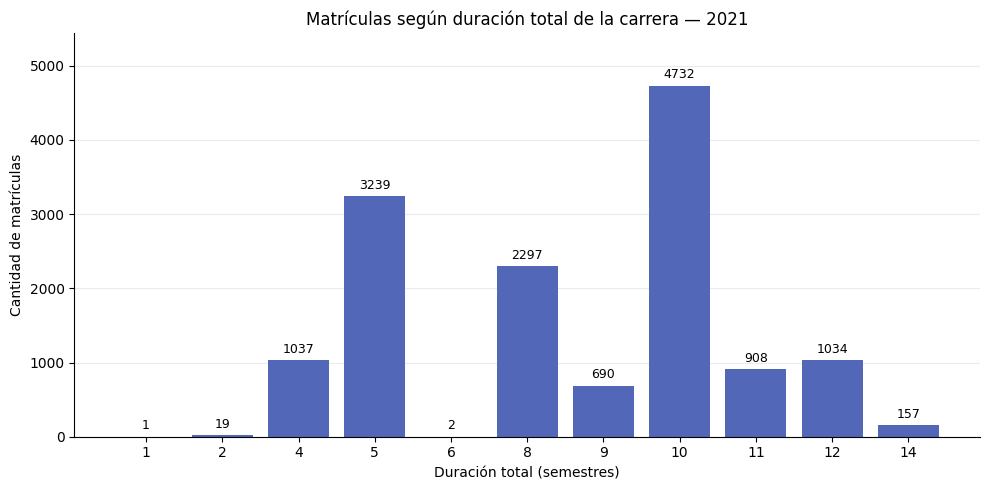

In [5]:
fig, ax = plt.subplots()
barras = ax.bar(tabla_frecuencia['Duración (semestres)'].astype(str),
                tabla_frecuencia['Frecuencia'], color='#5267B8')
ax.bar_label(barras, padding=3, fontsize=9)
ax.set(title='Matrículas según duración total de la carrera — 2021',
       xlabel='Duración total (semestres)', ylabel='Cantidad de matrículas')
ax.set_ylim(0, tabla_frecuencia['Frecuencia'].max() * 1.15)
ax.set_axisbelow(True)
ax.grid(axis='y', alpha=.25)
fig.tight_layout()
plt.tight_layout()
plt.show()

**Interpretación del gráfico:** las barras permiten comparar cada duración discreta. Destacan tres concentraciones en **10, 5 y 8 semestres**; la frecuencia no aumenta de forma continua con la duración. El gráfico representa matrículas, por lo que una barra alta no implica una mayor cantidad de carreras diferentes.

## 3. Género registrado
Se utilizan una tabla de frecuencias, porcentajes, un gráfico de barras y la moda como medida de tendencia central. No corresponde calcular media, mediana, percentiles ni frecuencias acumuladas para estas categorías nominales, porque no tienen un orden numérico.

,Género,Frecuencia,Porcentaje
0,Femenino,7993,56.62
1,Masculino,6123,43.38


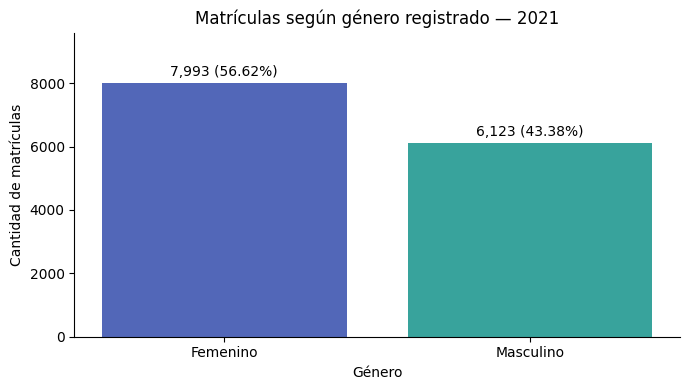

In [6]:
frecuencia_genero = genero.value_counts()
tabla_genero = frecuencia_genero.rename_axis('Género').reset_index(name='Frecuencia')
tabla_genero['Porcentaje'] = (tabla_genero['Frecuencia'] / genero.count() * 100).round(2)
display(tabla_genero)

fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.bar(tabla_genero['Género'], tabla_genero['Frecuencia'],
                color=['#5267B8', '#38A39C'])
ax.bar_label(barras, labels=[f'{n:,} ({p:.2f}%)' for n, p in
                            zip(tabla_genero['Frecuencia'], tabla_genero['Porcentaje'])], padding=3)
ax.set(title='Matrículas según género registrado — 2021', ylabel='Cantidad de matrículas', xlabel='Género')
ax.set_ylim(0, tabla_genero['Frecuencia'].max() * 1.2)
fig.tight_layout()
plt.tight_layout()
plt.show()

**Interpretación de la tabla y del gráfico:** la categoráa modal es **Femenino**, con **7.993 matrículas (56,62%)**. Masculino registra **6.123 (43,38%)**. La diferencia es de **1.870 matrículas** y **13,25 puntos porcentuales**. La barra de Femenino es más alta, aunque ambas categorías tienen una participación considerable. Esto describe la composición del archivo; no permite explicar las causas de la diferencia.

## 4. Área de conocimiento
Se utilizan una tabla de frecuencias, porcentajes, un gráfico de barras y la moda como medida de tendencia central. Las áreas se ordenan de mayor a menor frecuencia para facilitar la comparación. Este orden no convierte la variable en ordinal: no corresponde calcular media, mediana, percentiles ni frecuencias acumuladas.

,Área de conocimiento,Frecuencia,Porcentaje
0,Tecnologia,2979,21.10
1,Salud,2899,20.54
2,Administracion y Comercio,2254,15.97
3,Educacion,2060,14.59
4,Ciencias Sociales,1972,13.97
5,Derecho,751,5.32
6,Agropecuaria,534,3.78
7,Arte y Arquitectura,249,1.76
8,Humanidades,231,1.64
9,Ciencias Basicas,187,1.32


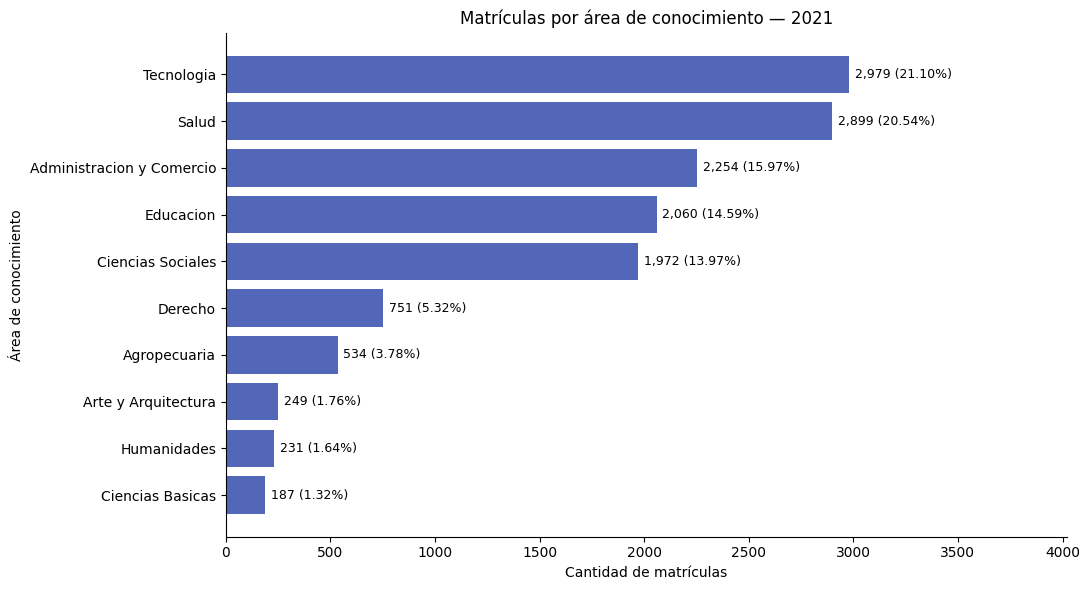

In [7]:
frecuencia_area = area.value_counts()
tabla_area = frecuencia_area.rename_axis('Área de conocimiento').reset_index(name='Frecuencia')
tabla_area['Porcentaje'] = (tabla_area['Frecuencia'] / area.count() * 100).round(2)
display(tabla_area)

fig, ax = plt.subplots(figsize=(11, 6))
barras = ax.barh(tabla_area['Área de conocimiento'], tabla_area['Frecuencia'], color='#5267B8')
ax.invert_yaxis()
ax.bar_label(barras, labels=[f'{n:,} ({p:.2f}%)' for n, p in
                            zip(tabla_area['Frecuencia'], tabla_area['Porcentaje'])], padding=4, fontsize=9)
ax.set(title='Matrículas por área de conocimiento — 2021', xlabel='Cantidad de matrículas', ylabel='Área de conocimiento')
ax.set_xlim(0, tabla_area['Frecuencia'].max() * 1.35)
fig.tight_layout()
plt.tight_layout()
plt.show()

**Interpretación:** Tecnología es el área modal con **2.979 matrículas (21,10%)**, seguida de Salud con **2.899 (20,54%)** y Administración y Comercio con **2.254 (15,97%)**. Estas tres áreas reúnen el **57,61%** del total.

Ciencias Básicas tiene la menor frecuencia, con **187 matrículas (1,32%)**. Las diferencias reflejan el volumen de matrícula por área en este archivo; no miden calidad, empleabilidad ni demanda laboral.

## 5. Edad

**Criterio de intervalos**: se utiliza la regla de Sturges, $k = 1 + \log_2(n)$. Sturges da $k \approx 15$; se usan 15 intervalos de ancho fijo 4 años
entre 16 y 76 años. En `pd.cut` los intervalos se cierran a la derecha; el primero incluye también el límite inferior.

En las tablas, **fi** es la frecuencia absoluta, **hi** el porcentaje, **Fi** la frecuencia acumulada y **Hi** el porcentaje acumulado. Los cálculos de medidas y percentiles usan los datos originales, sin agrupar.

In [8]:
#Sturges e intervalos de ancho fijo 4 años
k = int(round(1 + np.log2(df.shape[0])))   # k = 15
intervalos_edad = np.arange(16, 77, 4)     # [16,20], (20,24], ..., (72,76]

df['Intervalos EDAD'] = pd.cut(df['EDAD'], bins=intervalos_edad, include_lowest=True, precision=0)
frecuencia = df.groupby('Intervalos EDAD', observed=True).size()

n = df.shape[0]
tabla_edad = pd.DataFrame({
    'fi': frecuencia,
    'hi': round((frecuencia/n)*100, 1),
    'Fi': frecuencia.cumsum(),
    'Hi': round(((frecuencia/n)*100).cumsum(), 1)
})
print(f"k de Sturges = {k}")
tabla_edad

k de Sturges = 15


,fi,hi,Fi,Hi
Intervalos EDAD,,,,
"(15, 20]",3209,22.70,3209,22.70
"(20, 24]",5778,40.90,8987,63.70
"(24, 28]",1857,13.20,10844,76.80
"(28, 32]",1152,8.20,11996,85.00
"(32, 36]",756,5.40,12752,90.30
"(36, 40]",510,3.60,13262,94.00
"(40, 44]",342,2.40,13604,96.40
"(44, 48]",243,1.70,13847,98.10
"(48, 52]",155,1.10,14002,99.20


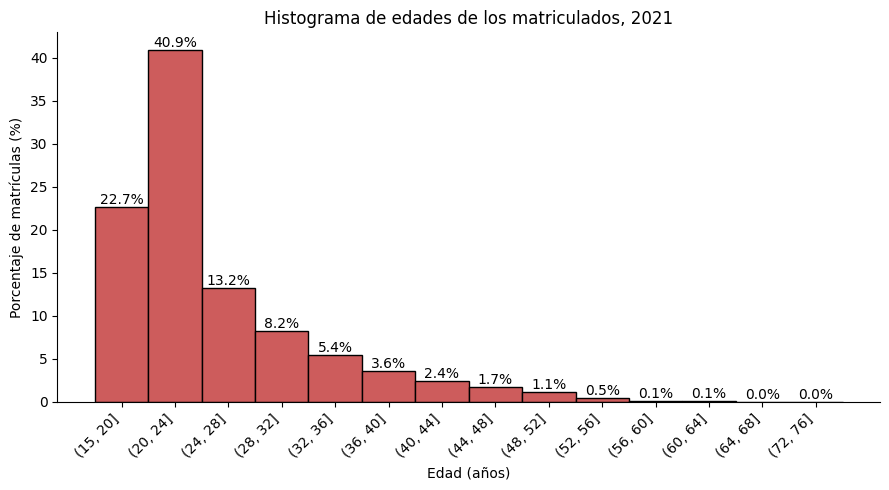

In [9]:
#Histograma: EDAD
fig, ax = plt.subplots(figsize=(9,5))
histograma = ax.bar(tabla_edad.index.astype(str), tabla_edad['hi'], color='indianred', edgecolor='black', width=1)
ax.set_title('Histograma de edades de los matriculados, 2021')
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Porcentaje de matrículas (%)')
ax.bar_label(histograma, fmt='%.1f%%')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
#Medidas de tendencia central y percentiles: EDAD
media_edad = df['EDAD'].mean()
mediana_edad = df['EDAD'].median()
moda_edad = df['EDAD'].mode()[0]
p25_edad = df['EDAD'].quantile(0.25)
p50_edad = df['EDAD'].quantile(0.50)
p75_edad = df['EDAD'].quantile(0.75)
p90_edad = df['EDAD'].quantile(0.90)

resumen_edad = pd.DataFrame({
    'Medida': ['Media', 'Mediana', 'Moda', 'P25', 'P50', 'P75', 'P90', 'Mínimo', 'Máximo'],
    'Valor': [round(media_edad,1), mediana_edad, moda_edad, p25_edad, p50_edad, p75_edad, p90_edad,
              df['EDAD'].min(), df['EDAD'].max()]
})
resumen_edad

,Medida,Valor
0,Media,25.50
1,Mediana,23.00
2,Moda,19.00
3,P25,21.00
4,P50,23.00
5,P75,28.00
6,P90,36.00
7,Mínimo,18.00
8,Máximo,75.00


**Interpretación de la edad:** la media es de **25,5 años**, la mediana de **23** y la moda de **19**. El histograma muestra concentración en edades jóvenes y una cola hacia edades mayores; se observan registros de hasta **75 años**. Los percentiles 25 y 75 son **21 y 28 años**, y el percentil 90 es **36 años**. Por las edades repetidas, este último valor no implica que exactamente el 10% tenga 36 años o más. Estos resultados describen edades registradas, sin establecer si las personas se incorporan por primera vez o retoman sus estudios.

## 6. Valor del arancel

**Criterio de intervalos**: Sturges da $k \approx 15$; se usan intervalos de ancho fijo
\$400.000 entre \$0 y \$6.000.000.

In [11]:
#Intervalos de ancho fijo $400.000 (k = 15 según Sturges)
intervalos_arancel = np.arange(0, 6000001, 400000)

df['Intervalos ARANCEL'] = pd.cut(df['VALOR ARANCEL (PESOS)'], bins=intervalos_arancel,
                                  include_lowest=True, precision=0)
frecuencia = df.groupby('Intervalos ARANCEL', observed=True).size()

tabla_arancel = pd.DataFrame({
    'fi': frecuencia,
    'hi': round((frecuencia/n)*100, 1),
    'Fi': frecuencia.cumsum(),
    'Hi': round(((frecuencia/n)*100).cumsum(), 1)
})
tabla_arancel

,fi,hi,Fi,Hi
Intervalos ARANCEL,,,,
"(-1, 400000]",6,0.00,6,0.00
"(400000, 800000]",44,0.30,50,0.40
"(800000, 1200000]",4,0.00,54,0.40
"(1200000, 1600000]",2507,17.80,2561,18.10
"(1600000, 2000000]",1708,12.10,4269,30.20
"(2000000, 2400000]",1604,11.40,5873,41.60
"(2400000, 2800000]",488,3.50,6361,45.10
"(2800000, 3200000]",1857,13.20,8218,58.20
"(3200000, 3600000]",3667,26.00,11885,84.20


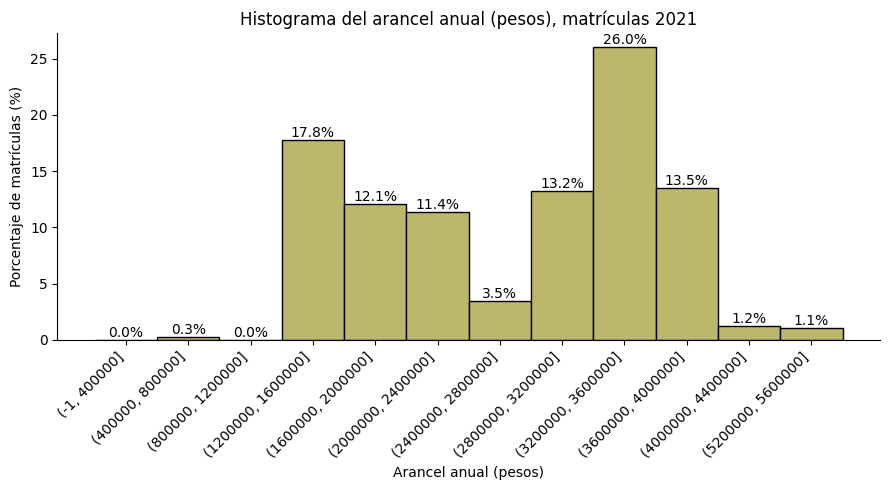

In [12]:
#Histograma: VALOR ARANCEL (PESOS)
fig, ax = plt.subplots(figsize=(9,5))
histograma = ax.bar(tabla_arancel.index.astype(str), tabla_arancel['hi'], color='darkkhaki', edgecolor='black', width=1)
ax.set_title('Histograma del arancel anual (pesos), matrículas 2021')
ax.set_xlabel('Arancel anual (pesos)')
ax.set_ylabel('Porcentaje de matrículas (%)')
ax.bar_label(histograma, fmt='%.1f%%')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
#Medidas de tendencia central y percentiles: VALOR ARANCEL
arancel = df['VALOR ARANCEL (PESOS)']

media_arancel = arancel.mean()
mediana_arancel = arancel.median()
moda_arancel = arancel.mode()[0]
p25_arancel = arancel.quantile(0.25)
p75_arancel = arancel.quantile(0.75)
p90_arancel = arancel.quantile(0.90)
p95_arancel = arancel.quantile(0.95)

resumen_arancel = pd.DataFrame({
    'Medida': ['Media', 'Mediana', 'Moda', 'P25', 'P75', 'P90', 'P95', 'Mínimo', 'Máximo'],
    'Valor': [round(media_arancel), mediana_arancel, moda_arancel, p25_arancel, p75_arancel,
              p90_arancel, p95_arancel, arancel.min(), arancel.max()]
})
resumen_arancel

,Medida,Valor
0,Media,"2,714,574.00"
1,Mediana,"2,857,000.00"
2,Moda,"3,533,000.00"
3,P25,"1,850,000.00"
4,P75,"3,533,000.00"
5,P90,"3,775,000.00"
6,P95,"3,995,000.00"
7,Mínimo,0.00
8,Máximo,"5,595,000.00"


**Interpretación del arancel:** la media es de **$2.714.574**, la mediana de **$2.857.000** y la moda de **$3.533.000**. La media es inferior a la mediana, pero esa comparación por sí sola no determina la forma completa de la distribución. La tabla y el histograma permiten observar las concentraciones de aranceles por intervalo.

Los percentiles 25 y 75 son **$1.850.000 y $3.533.000**. El percentil 95 es **$3.995.000**; por los valores repetidos no debe interpretarse como que exactamente el 5% supera ese importe. Existen **5 registros con arancel cero**; se conservan porque el archivo no explica si corresponden a una exención o a otra situación. Se compara el arancel registrado, no el pago efectivo después de beneficios ni el costo total de la carrera.

## 7. Valor de matrícula

**Criterio de intervalos**: Sturges da $k \approx 15$; se usan intervalos de ancho fijo
\$20.000 entre \$0 y \$300.000.

In [14]:
#Intervalos de ancho fijo $20.000 (k = 15 según Sturges)
intervalos_matricula = np.arange(0, 300001, 20000)

df['Intervalos MATRICULA'] = pd.cut(df['VALOR MATRICULA (PESOS)'], bins=intervalos_matricula,
                                    include_lowest=True, precision=0)
frecuencia = df.groupby('Intervalos MATRICULA', observed=True).size()

tabla_matricula = pd.DataFrame({
    'fi': frecuencia,
    'hi': round((frecuencia/n)*100, 1),
    'Fi': frecuencia.cumsum(),
    'Hi': round(((frecuencia/n)*100).cumsum(), 1)
})
tabla_matricula

,fi,hi,Fi,Hi
Intervalos MATRICULA,,,,
"(-1, 20000]",1902,13.50,1902,13.50
"(40000, 60000]",62,0.40,1964,13.90
"(60000, 80000]",717,5.10,2681,19.00
"(80000, 100000]",548,3.90,3229,22.90
"(100000, 120000]",858,6.10,4087,29.00
"(120000, 140000]",787,5.60,4874,34.50
"(140000, 160000]",6998,49.60,11872,84.10
"(160000, 180000]",228,1.60,12100,85.70
"(180000, 200000]",198,1.40,12298,87.10


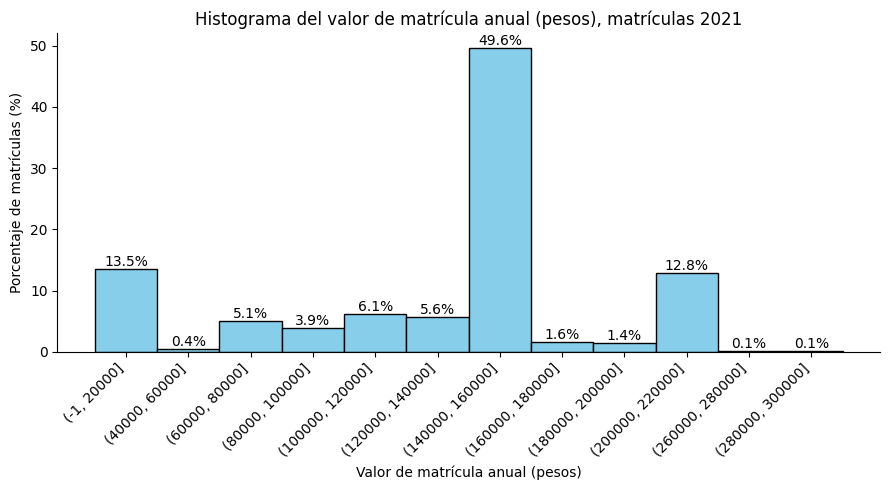

In [15]:
#Histograma: VALOR MATRICULA (PESOS)
fig, ax = plt.subplots(figsize=(9,5))
histograma = ax.bar(tabla_matricula.index.astype(str), tabla_matricula['hi'], color='skyblue', edgecolor='black', width=1)
ax.set_title('Histograma del valor de matrícula anual (pesos), matrículas 2021')
ax.set_xlabel('Valor de matrícula anual (pesos)')
ax.set_ylabel('Porcentaje de matrículas (%)')
ax.bar_label(histograma, fmt='%.1f%%')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
#Medidas de tendencia central y percentiles: VALOR MATRICULA
matricula = df['VALOR MATRICULA (PESOS)']

media_mat = matricula.mean()
mediana_mat = matricula.median()
moda_mat = matricula.mode()[0]
p25_mat = matricula.quantile(0.25)
p75_mat = matricula.quantile(0.75)
p90_mat = matricula.quantile(0.90)

resumen_matricula = pd.DataFrame({
    'Medida': ['Media', 'Mediana', 'Moda', 'P25', 'P75', 'P90', 'Mínimo', 'Máximo'],
    'Valor': [round(media_mat), mediana_mat, moda_mat, p25_mat, p75_mat, p90_mat,
              matricula.min(), matricula.max()]
})
resumen_matricula

,Medida,Valor
0,Media,"131,952.00"
1,Mediana,"155,000.00"
2,Moda,"155,000.00"
3,P25,"116,000.00"
4,P75,"155,000.00"
5,P90,"220,000.00"
6,Mínimo,0.00
7,Máximo,"290,504.00"


**Interpretación del valor de matrícula:** la media es de **$131.952** y la mediana de **$155.000**. La moda y el percentil 75 también son **$155.000**, lo que muestra una concentración de registros en ese importe. El histograma permite distinguir grupos de valores y una concentración alrededor del intervalo que contiene la moda.

Los importes bajos o iguales a cero no demuestran la existencia de becas o beneficios: el archivo no permite establecer su causa. Tampoco se presupone que cada institución cobre un único valor. Estos importes corresponden al valor de matrícula registrado y se distinguen del arancel.

## 8. Tipo de institución

In [17]:
#Tabla de frecuencia: TIPO DE INSTITUCION (ordenada de mayor a menor fi)
frecuencia = df.groupby('TIPO DE INSTITUCION').size().sort_values(ascending=False)

tabla_tipo_inst = pd.DataFrame({
    'fi': frecuencia,
    'hi': round((frecuencia/n)*100, 1),
})

frec_institucion = df.groupby('NOMBRE DE INSTITUCION').size().sort_values(ascending=False)
tabla_instituciones = pd.DataFrame({'Matrículas': frec_institucion,
                                    'hi (%)': round((frec_institucion/n)*100, 1)})

display(tabla_tipo_inst)
display(tabla_instituciones.head(5))

,fi,hi
TIPO DE INSTITUCION,,
Universidades CRUCH,7849,55.60
Centros de Formacion Tecnica,3594,25.50
Institutos Profesionales,1430,10.10
Universidades Privadas,1243,8.80


,Matrículas,hi (%)
NOMBRE DE INSTITUCION,,
UNIVERSIDAD DE TARAPACA,7119,50.40
CFT DE LA REGION DE ARICA Y PARINACOTA,1896,13.40
UNIVERSIDAD SANTO TOMAS,898,6.40
CFT INACAP,807,5.70
IP INACAP,789,5.60


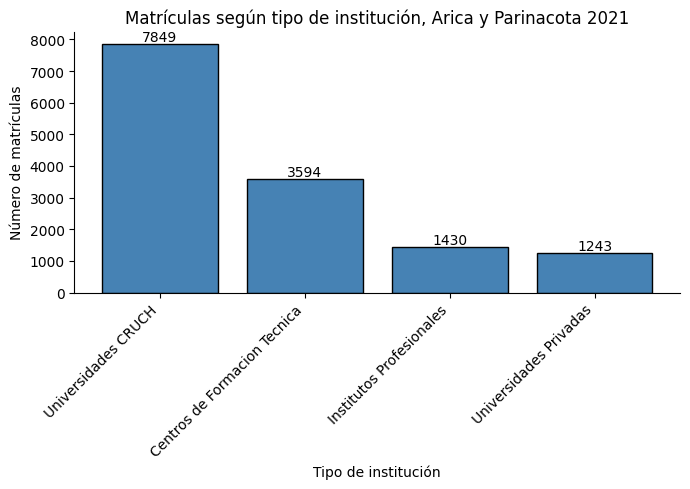

In [18]:
#Gráfico de barras: TIPO DE INSTITUCION
categorias = tabla_tipo_inst.index
f = tabla_tipo_inst['fi']

fig, ax = plt.subplots(figsize=(7,5))
barras = ax.bar(categorias, f, color='steelblue', edgecolor='black')
ax.set_title('Matrículas según tipo de institución, Arica y Parinacota 2021')
ax.set_xlabel('Tipo de institución')
ax.set_ylabel('Número de matrículas')
ax.bar_label(barras)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Interpretación — `TIPO DE INSTITUCION`**: las **Universidades CRUCH** concentran el 55,6 % de las
matrículas (7.849) y son la moda, seguidas por los **Centros de Formación Técnica** con 25,5 %. Los
Institutos Profesionales (10,1 %) y las Universidades Privadas (8,8 %) tienen participaciones menores.
A nivel de institución específica, la **Universidad de Tarapacá** (estatal, CRUCH) concentra por sí
sola el **50,4 %** de toda la matrícula regional (7.119 de 14.116), seguida de lejos por el CFT de la
Región de Arica y Parinacota (13,4 %) y la Universidad Santo Tomás (6,4 %). La matrícula del archivo está, por tanto, concentrada en esa institución; esto no mide la cantidad de programas ofrecidos.

## 9. Jornada

In [19]:
#Tabla de frecuencia: JORNADA (ordenada de mayor a menor fi)
frecuencia = df.groupby('JORNADA').size().sort_values(ascending=False)

tabla_jornada = pd.DataFrame({
    'fi': frecuencia,
    'hi': round((frecuencia/n)*100, 1),
})
tabla_jornada

,fi,hi
JORNADA,,
Diurno,9961,70.60
Vespertino,4104,29.10
Otro,47,0.30
Semipresencial,4,0.00


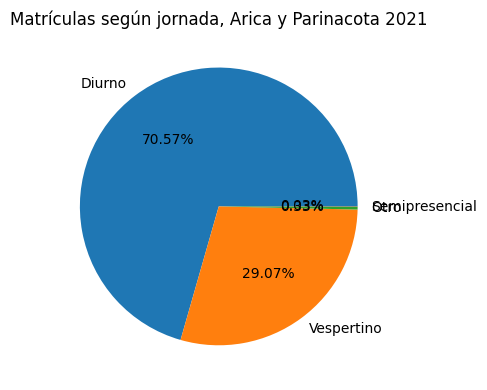

In [20]:
#Gráfico circular: JORNADA
categorias = tabla_jornada.index
h = tabla_jornada['fi']

fig, ax = plt.subplots(figsize=(6,4))
ax.pie(h, labels=categorias, autopct='%.2f%%')
ax.set_title('Matrículas según jornada, Arica y Parinacota 2021')
plt.tight_layout()
plt.show()

**Interpretación de la jornada:** la moda es **Diurno**, con **9.961 matrículas (70,57%)**; **Vespertino** reúne **4.104 (29,07%)**. Hay **47 registros en Otro (0,33%)** y **4 en Semipresencial (0,03%)**; el redondeo a un decimal de la tabla no significa que esta última categoría esté vacía.

La mayor parte de las matrículas corresponde a jornada diurna. La jornada no permite establecer por sí sola la modalidad presencial ni la situación laboral de las personas. Como variable nominal, se describe con frecuencias, porcentajes y moda, sin medias ni percentiles.

## 10. Síntesis del análisis descriptivo

- **Duración:** el promedio por matrícula es de **8,28 semestres**, la mediana es **9** y la moda es **10**. Los percentiles 25, 50 y 75 son **5, 9 y 10 semestres**. Entre 5 y 10 semestres se concentra el **77,64%** de las matrículas.
- **Género:** Femenino es la categoría modal, con **56,62%** de las matrículas, frente a **43,38%** de Masculino.
- **Área de conocimiento:** Tecnología es el área modal. Junto con Salud y Administración y Comercio concentra el **57,61%** de las matrículas.

- **Edad:** la mediana es de 23 años y la moda de 19.
- **Costos registrados:** las medianas del arancel y del valor de matrícula son $2.857.000 y $155.000, respectivamente.
- **Tipo de institución y jornada:** las universidades CRUCH concentran el 55,6% de las matrículas; la jornada diurna representa el 70,57%.

**Alcance:** los resultados corresponden a matrículas registradas en Arica y Parinacota en 2021. No representan necesariamente personas únicas ni la duración efectiva hasta la titulación, y no permiten establecer relaciones causales. Los valores poco frecuentes se conservaron porque no hay evidencia suficiente para considerarlos errores.

# Ítem 2 | Pregunta 1
## ¿Hay áreas del conocimiento donde las carreras sean más caras? Expliquen qué criterio diseñaron para responder la pregunta.

### Criterio de comparación
Para esta pregunta incorporamos **VALOR ARANCEL (PESOS)** y lo agrupamos por **AREA CONOCIMIENTO**. Definimos como áreas de arancel más alto aquellas cuya **mediana del arancel supera la mediana general de los registros**. Ordenamos las áreas por su mediana e identificamos la mayor.

Elegimos la **mediana (percentil 50)** porque representa la posición central y es menos sensible a valores extremos que la media. Mostramos también la media para comprobar cómo cambia la comparación según el criterio. No usamos la suma de aranceles por área, porque depende de la cantidad de matrículas y no representa el precio típico.

El indicador es el **arancel registrado en pesos**, sin agregar el valor de matrícula ni multiplicarlo por la duración. Por tanto, **más caras** se entiende aquí como **mayor arancel típico registrado**, no como mayor costo total de completar una carrera. Cada fila conserva su peso como registro de matrícula.

In [21]:
col_arancel = 'VALOR ARANCEL (PESOS)'
col_area = 'AREA CONOCIMIENTO'
datos_costos = df[[col_area, col_arancel]].copy()
print('Aranceles faltantes:', datos_costos[col_arancel].isna().sum())
print('Aranceles negativos:', (datos_costos[col_arancel] < 0).sum())
print('Aranceles iguales a cero:', (datos_costos[col_arancel] == 0).sum())
print('Áreas faltantes:', datos_costos[col_area].isna().sum())

costos_validos = datos_costos.loc[
    datos_costos[col_area].notna() & datos_costos[col_arancel].notna()
    & (datos_costos[col_arancel] >= 0)
].copy()
mediana_general = costos_validos[col_arancel].median()
resumen_costos = costos_validos.groupby(col_area).agg(
    Registros=(col_arancel, 'count'),
    Mediana_arancel=(col_arancel, 'median'),
    Media_arancel=(col_arancel, 'mean')
).sort_values('Mediana_arancel', ascending=False)
resumen_costos['Supera mediana general'] = resumen_costos['Mediana_arancel'].gt(mediana_general).map({True: 'Sí', False: 'No'})
print(f'Mediana general del arancel: ${mediana_general:,.0f} pesos')
display(resumen_costos.rename(columns={
    'Mediana_arancel': 'Mediana del arancel (pesos)',
    'Media_arancel': 'Media del arancel (pesos)'
}))

medianas_sin_ceros = costos_validos.loc[costos_validos[col_arancel] > 0].groupby(col_area)[col_arancel].median()
print('¿Cambian las medianas por área al excluir ceros?',
      not resumen_costos['Mediana_arancel'].eq(medianas_sin_ceros.reindex(resumen_costos.index)).all())
print('Mediana general sin ceros:', costos_validos.loc[costos_validos[col_arancel] > 0, col_arancel].median())

Aranceles faltantes: 0
Aranceles negativos: 0
Aranceles iguales a cero: 5
Áreas faltantes: 0
Mediana general del arancel: $2,857,000 pesos
¿Cambian las medianas por área al excluir ceros? False
Mediana general sin ceros: 2857000.0


,Registros,Mediana del arancel (pesos),Media del arancel (pesos),Supera mediana general
AREA CONOCIMIENTO,,,,
Derecho,751,"3,995,000.00","3,282,807.72",Sí
Ciencias Basicas,187,"3,533,000.00","2,834,019.18",Sí
Salud,2899,"3,533,000.00","3,320,545.86",Sí
Tecnologia,2979,"3,533,000.00","2,874,100.85",Sí
Arte y Arquitectura,249,"3,363,000.00","2,854,626.51",Sí
Humanidades,231,"3,034,000.00","2,615,472.73",Sí
Ciencias Sociales,1972,"2,857,000.00","2,576,016.51",No
Educacion,2060,"2,160,000.00","2,148,344.49",No
Administracion y Comercio,2254,"1,855,000.00","2,227,579.46",No


**Interpretación de la revisión y de la tabla:** no hay aranceles faltantes ni negativos. Hay **5 registros con arancel cero**, todos en Agropecuaria. Se conservaron porque no se conoce el motivo de ese valor; excluirlos no cambia las medianas de las áreas ni la mediana general.

La mediana general es **$2.857.000**. Según el criterio elegido, seis áreas la superan: **Derecho ($3.995.000)**; **Ciencias Básicas, Salud y Tecnología ($3.533.000 cada una)**; **Arte y Arquitectura ($3.363.000)** y **Humanidades ($3.034.000)**. Ciencias Sociales iguala la mediana general, por lo que no se clasifica como superior.

**Derecho tiene el mayor arancel mediano**. En cambio, al ordenar por la media, **Salud tiene el mayor promedio**, de aproximadamente **$3.320.546**, frente a **$3.282.808** de Derecho. Por eso es necesario explicitar el criterio: la mediana y la media resumen aspectos distintos de la distribución.

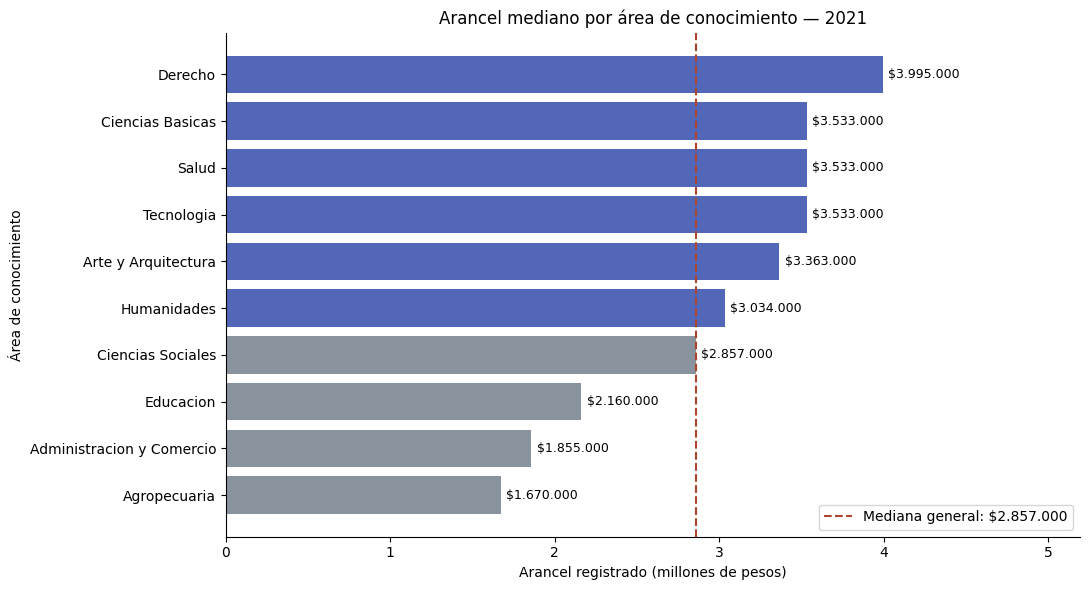

In [22]:
fig, ax = plt.subplots(figsize=(11, 6))
colores = ['#5267B8' if valor > mediana_general else '#89939E'
           for valor in resumen_costos['Mediana_arancel']]
barras = ax.barh(resumen_costos.index, resumen_costos['Mediana_arancel'] / 1_000_000,
                color=colores)
ax.invert_yaxis()
ax.bar_label(barras, labels=[f'${valor:,.0f}'.replace(',', '.')
                            for valor in resumen_costos['Mediana_arancel']], padding=4, fontsize=9)
ax.axvline(mediana_general / 1_000_000, color='#AD452D', linestyle='--',
           label='Mediana general: $2.857.000')
ax.set(title='Arancel mediano por área de conocimiento — 2021',
       xlabel='Arancel registrado (millones de pesos)', ylabel='Área de conocimiento',
       xlim=(0, resumen_costos['Mediana_arancel'].max() / 1_000_000 * 1.3))
ax.legend(loc='lower right')
fig.tight_layout()
plt.tight_layout()
plt.show()

**Interpretación del gráfico:** Derecho presenta la barra más larga. Ciencias Básicas, Salud y Tecnología comparten la segunda mediana más alta. Las seis barras azules superan la referencia general marcada con la línea vertical. Agropecuaria tiene la menor mediana (**$1.670.000**); la diferencia entre las medianas de Derecho y Agropecuaria es de **$2.325.000**. Esto compara valores centrales, no significa que todas las carreras de un área cuesten más que todas las de otra.

### Respuesta y limitaciones
**Sí: en este archivo hay áreas con un arancel típico más alto, según la mediana de los registros de matrícula. Derecho encabeza la comparación con $3.995.000.** La conclusión depende del criterio declarado; si se usara el promedio, Salud ocuparía el primer lugar.

- **Unidad de análisis:** una carrera con más matrículas pesa más en los resultados. No se calculó una mediana dando el mismo peso a cada carrera o programa único.
- **Composición de las áreas:** se agrupan instituciones, niveles de estudio, jornadas y modalidades diferentes. No se puede atribuir la diferencia de arancel exclusivamente al área de conocimiento ni afirmar que todas sus carreras sean más caras.
- **Alcance del precio:** el arancel registrado no demuestra cuánto pagó cada estudiante después de becas, gratuidad o descuentos. Tampoco incluye aquí matrícula, materiales, transporte u otros gastos, ni estima el costo de toda la carrera. Los resultados describen este archivo de Arica y Parinacota de 2021; no los precios actuales ni los de todo Chile.

# Ítem 2 | Pregunta 2
## ¿Qué influencia tiene la edad en el tipo de institución a la que ingresan los estudiantes?

**Criterio:** comparar el porcentaje de matrículas de cada tipo de institución dentro de cada rango de edad. Se utiliza una tabla de doble entrada y un **gráfico de cuatro barras agrupadas por rango de edad**: universidades CRUCH, CFT, IP y universidades privadas.

El denominador es el total de matrículas de cada rango de edad; por eso sus cuatro porcentajes suman aproximadamente 100%, salvo redondeo. Se comparan porcentajes para que los rangos con más registros no dominen el gráfico. Este análisis permite describir una asociación, no demostrar influencia causal.

In [23]:
# Porcentajes dentro de cada rango de edad.
orden_edades = ['15 a 19', '20 a 24', '25 a 29', '30 a 34', '35 a 39', '40 y mas']
orden_tipos = ['Universidades CRUCH', 'Centros de Formacion Tecnica',
               'Institutos Profesionales', 'Universidades Privadas']
# Quitar espacios finales de las etiquetas del Excel antes de ordenar.
rangos_edad = df['RANGO EDAD'].str.strip()
conteos_edad_tipo = pd.crosstab(rangos_edad, df['TIPO DE INSTITUCION']).reindex(
    index=orden_edades, columns=orden_tipos, fill_value=0)
tabla_edad_tipo = conteos_edad_tipo.div(conteos_edad_tipo.sum(axis=1), axis=0) * 100
display(tabla_edad_tipo.round(1))

TIPO DE INSTITUCION,Universidades CRUCH,Centros de Formacion Tecnica,Institutos Profesionales,Universidades Privadas
RANGO EDAD,,,,
15 a 19,68.30,19.90,7.00,4.70
20 a 24,60.60,21.70,9.20,8.40
25 a 29,50.60,27.50,12.10,9.80
30 a 34,39.30,35.30,14.80,10.60
35 a 39,37.10,37.50,12.40,13.10
40 y mas,33.30,40.20,12.20,14.20


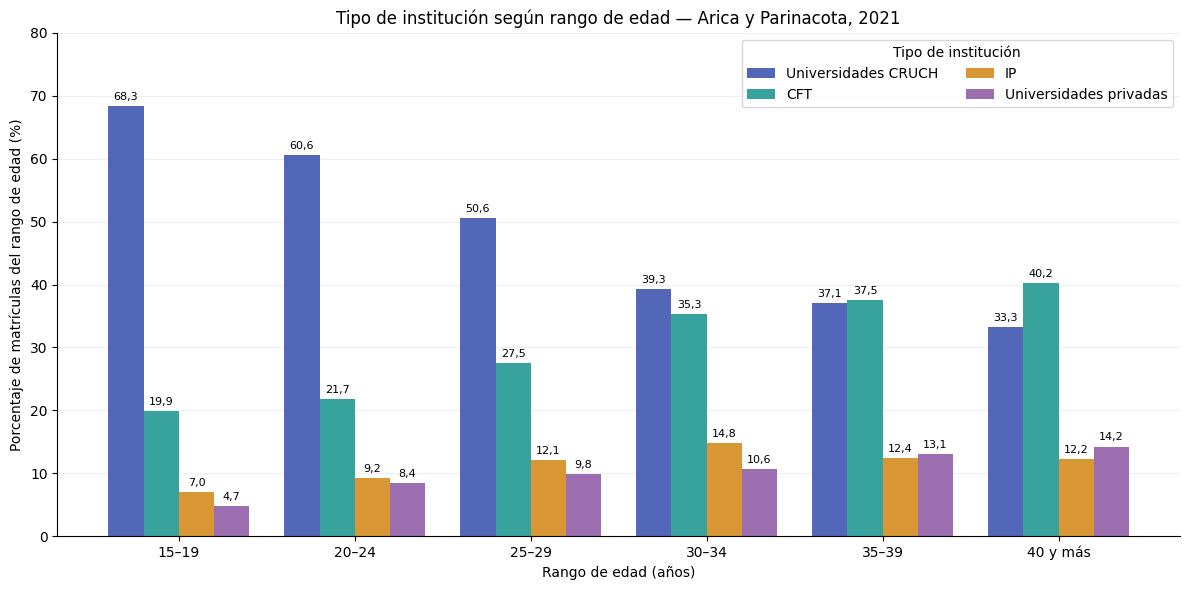

In [24]:
# Cuatro barras por rango, una para cada tipo de institución.
x = np.arange(len(tabla_edad_tipo))
ancho = 0.20
colores = ['#5267B8', '#38A39C', '#D99635', '#9C6DB0']
etiquetas = ['Universidades CRUCH', 'CFT', 'IP', 'Universidades privadas']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (tipo, etiqueta, color) in enumerate(zip(orden_tipos, etiquetas, colores)):
    barras = ax.bar(x + (i - 1.5) * ancho, tabla_edad_tipo[tipo],
                    width=ancho, label=etiqueta, color=color)
    ax.bar_label(barras, labels=[f'{valor:.1f}'.replace('.', ',')
                                for valor in tabla_edad_tipo[tipo]], padding=3, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(['15–19', '20–24', '25–29', '30–34', '35–39', '40 y más'])
ax.set(title='Tipo de institución según rango de edad — Arica y Parinacota, 2021',
       xlabel='Rango de edad (años)', ylabel='Porcentaje de matrículas del rango de edad (%)',
       ylim=(0, 80))
ax.set_axisbelow(True)
ax.grid(axis='y', alpha=0.2)
ax.legend(ncol=2, loc='upper right', title='Tipo de institución')
fig.tight_layout()
plt.show()

### Interpretación de la tabla y del gráfico

Las universidades CRUCH tienen la mayor participación en los rangos de **15–19, 20–24, 25–29 y 30–34 años**. Su porcentaje disminuye desde **68,3%** en el primer rango hasta **33,3%** en el de 40 años y más.

Los CFT aumentan su participación desde **19,9%** en el rango de 15–19 años hasta **40,2%** en el de 40 años y más. En los dos rangos de mayor edad son el tipo de institución con mayor participación: **37,5%** en 35–39 años y **40,2%** en 40 años y más. En el rango de 35–39 años la diferencia frente a CRUCH (**37,1%**) es pequeña.

Los IP y las universidades privadas tienen porcentajes menores que CRUCH y CFT en todos los rangos. En el de 40 años y más representan **12,2% y 14,2%**, respectivamente. Cada comparación se refiere a la distribución dentro del rango, no a cantidades absolutas de personas.

### Respuesta y limitaciones

**Se observa una asociación entre el rango de edad y el tipo de institución:** en los rangos más jóvenes predominan las matrículas en universidades CRUCH, mientras que en los dos rangos de mayor edad los CFT tienen la mayor participación. Por tanto, la composición institucional cambia según la edad registrada.

**No se puede afirmar que la edad cause la elección de institución.** Cada fila corresponde a una matrícula, no necesariamente a una persona única, y la edad registrada no equivale necesariamente a la edad de ingreso. Se consideran todas las matrículas del archivo, no solo las de primer ingreso. Otros factores, como los programas disponibles, podrían relacionarse con estas diferencias. El gráfico no permite deducir la situación laboral ni los motivos de elección, y la conclusión se limita a este archivo regional de 2021.